<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/LogisticRegression_On_Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn (1).csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.replace(" ",np.nan,inplace=True)

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


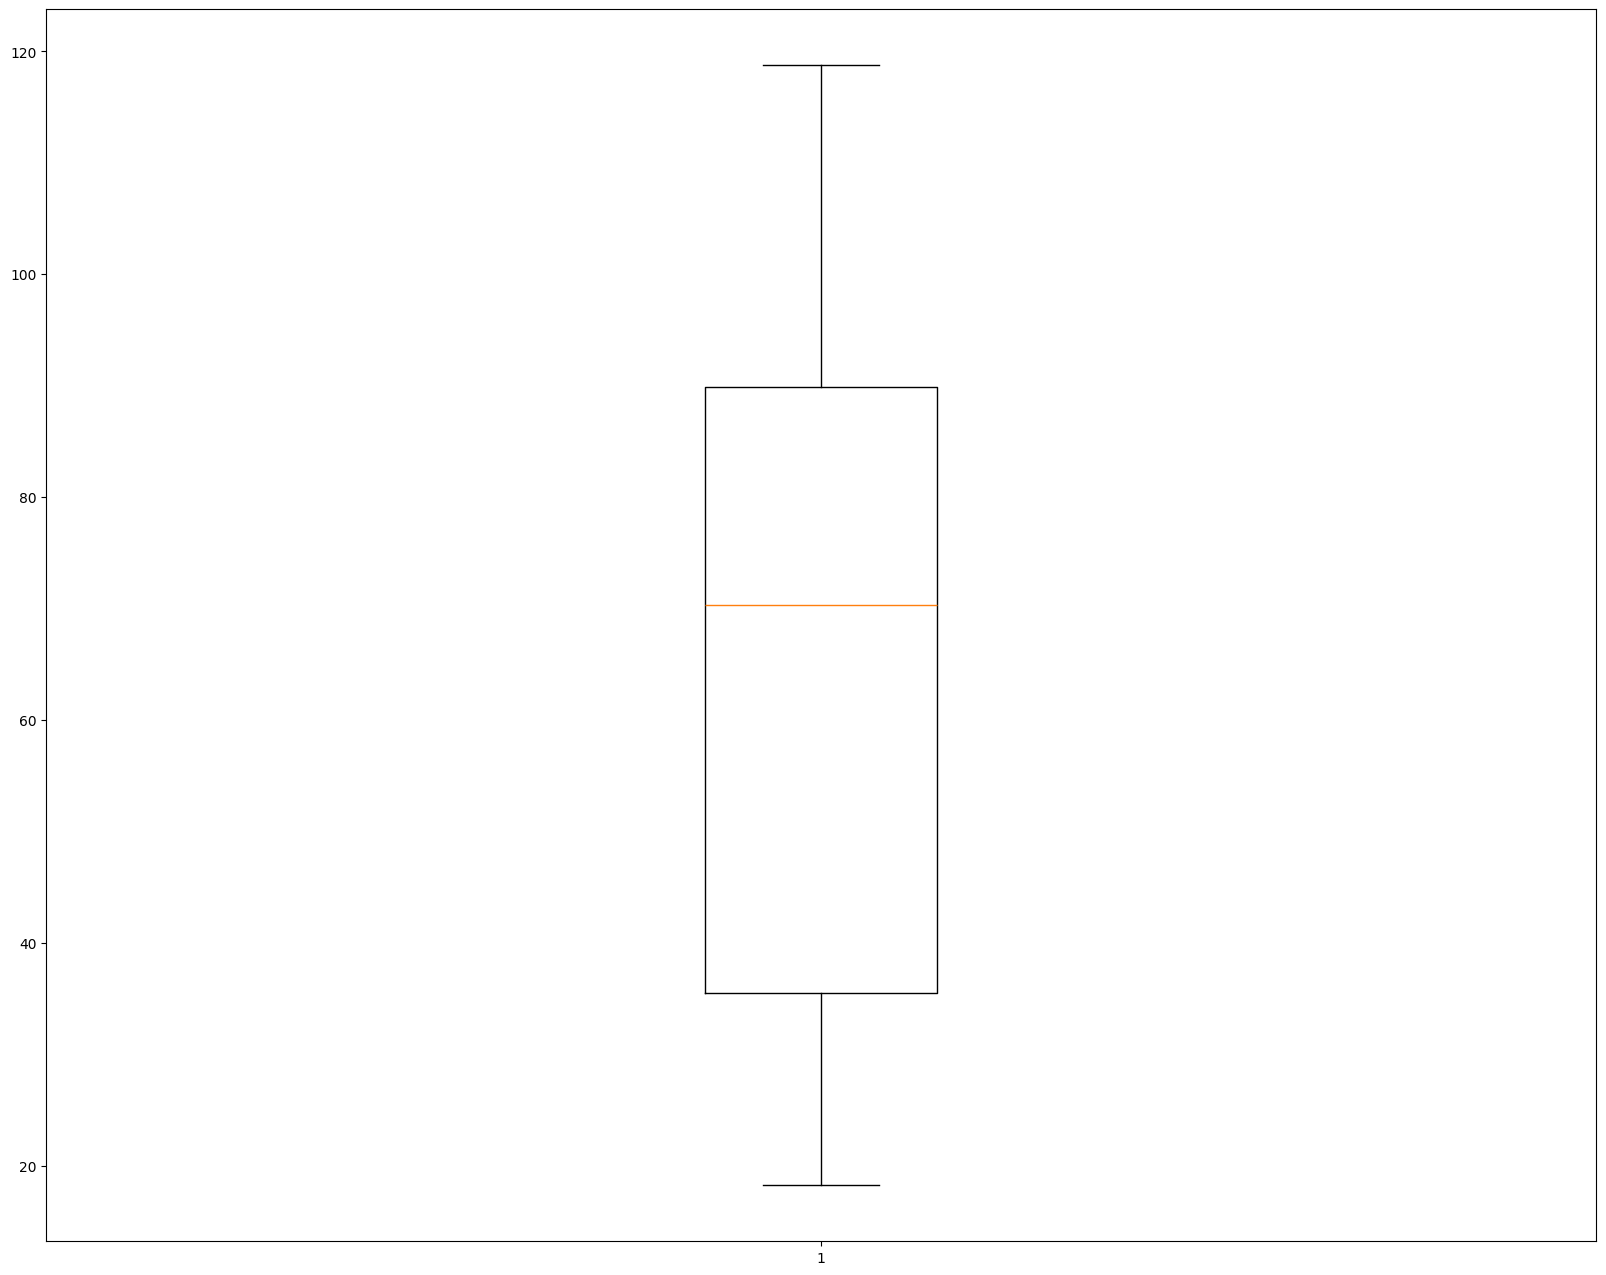

In [10]:
plt.figure(figsize=(20,16))
plt.boxplot(df['MonthlyCharges'])
plt.show()

In [12]:
df['TotalCharges'].dtype

dtype('O')

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [14]:
df = df.dropna(subset=['TotalCharges'])

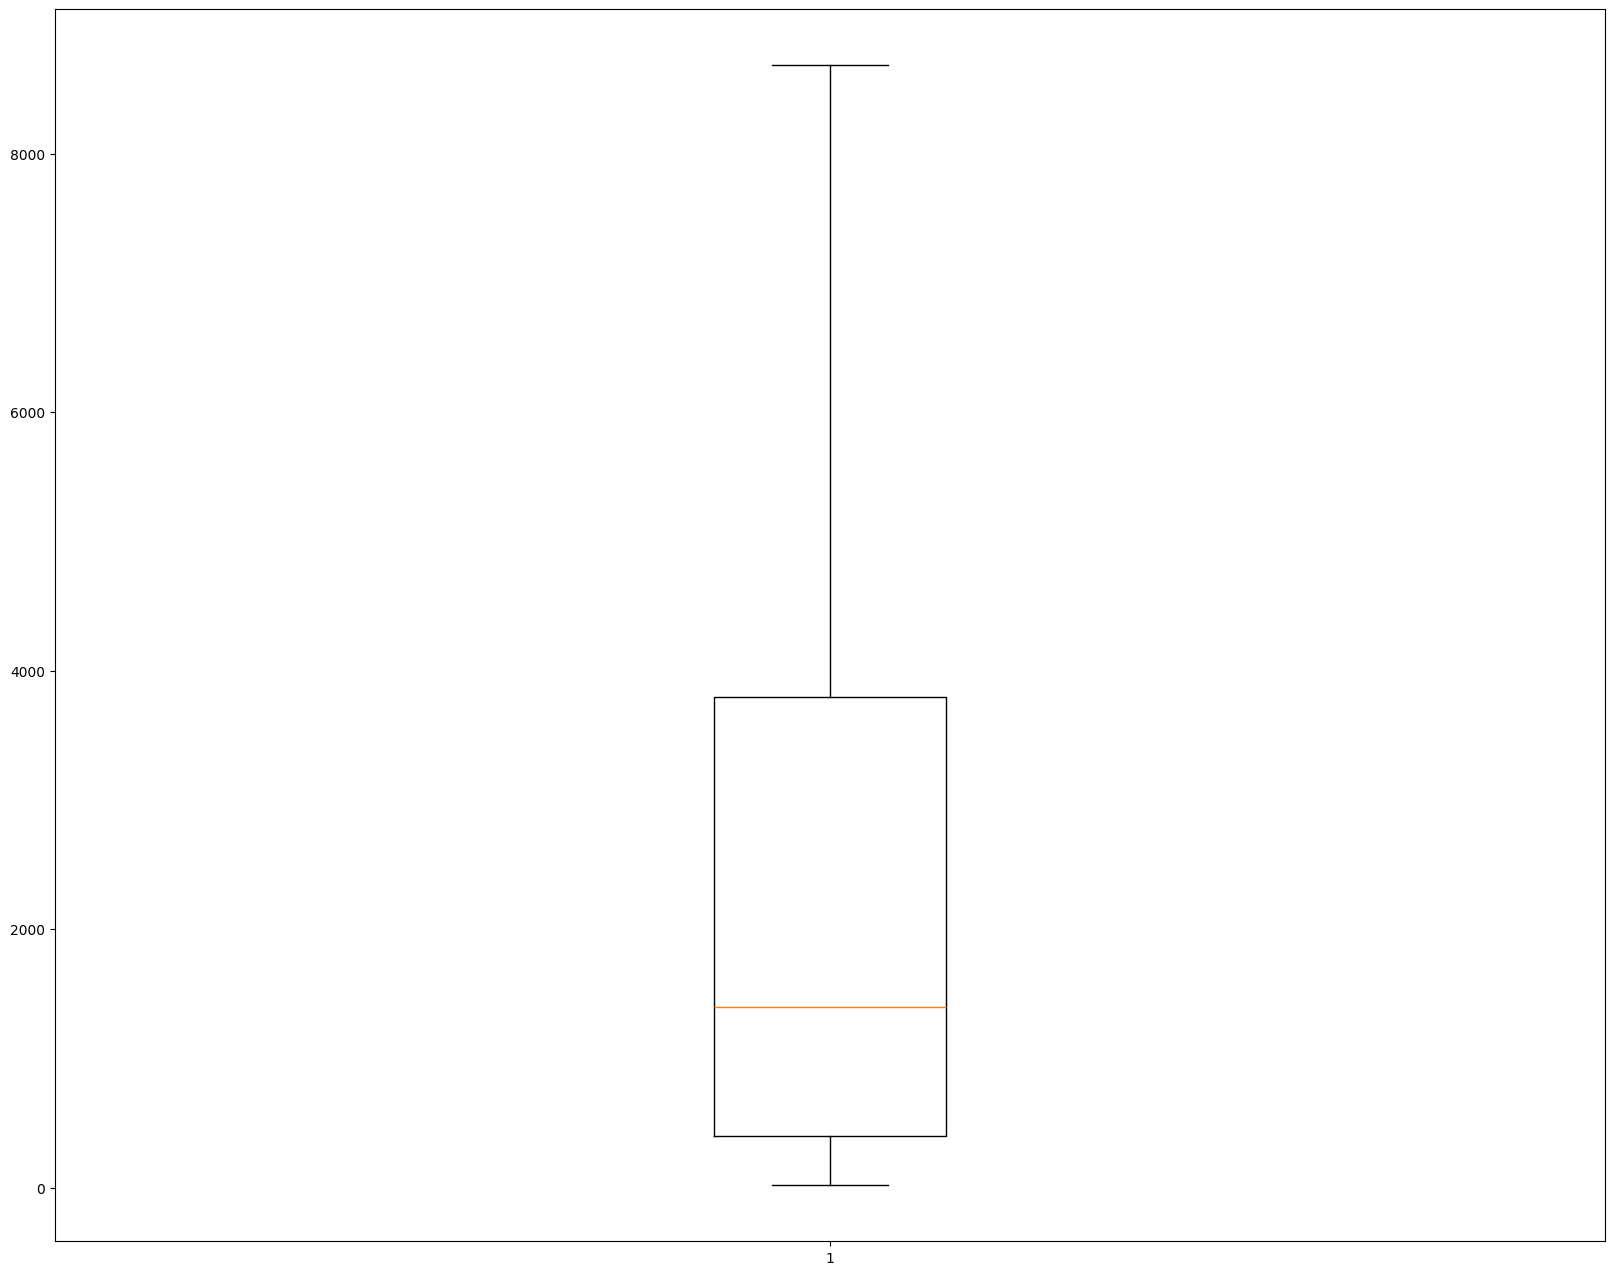

In [15]:
plt.figure(figsize=(20,16))
plt.boxplot(df['TotalCharges'])
plt.show()

In [16]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


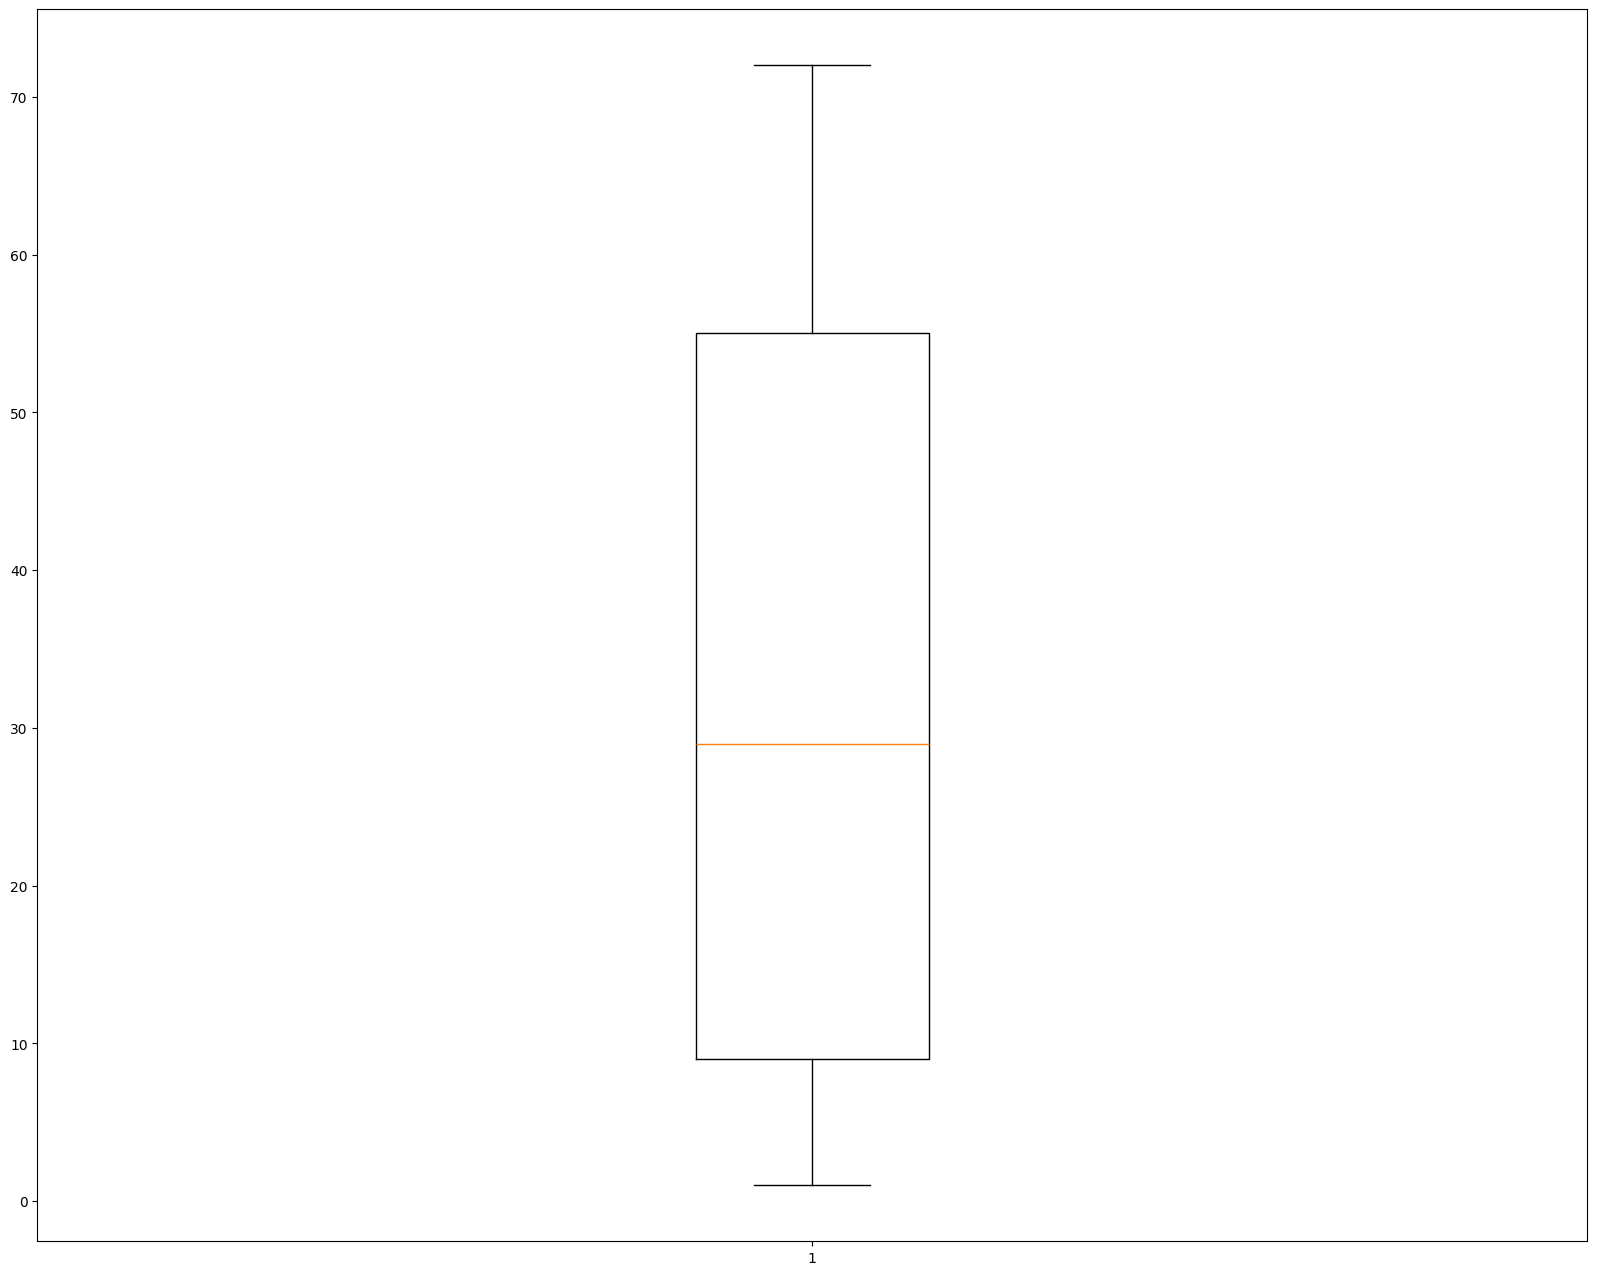

In [18]:
plt.figure(figsize=(20,16))
plt.boxplot(df['tenure'])
plt.show()

In [19]:
def remove_outliers(col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  return df[(df[col] > Q1 - IQR*1.5) & (df[col] <= Q3 + 1.5*IQR)]

df = remove_outliers('tenure')
df = remove_outliers('MonthlyCharges')
df = remove_outliers('TotalCharges')

In [20]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [23]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,60,72],
    labels = ['0-12','12-24','24-48','48-60','60-72']
)

In [24]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,24-48
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,24-48
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12


In [25]:
df['charges_per_month'] = df['TotalCharges']/(df['tenure']+1)

In [26]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,charges_per_month
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12,14.925000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,24-48,53.985714
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12,36.050000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,24-48,40.016304
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12,50.550000


In [27]:
df = pd.get_dummies(df,drop_first=True)

In [28]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,charges_per_month,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes,tenure_group_12-24,tenure_group_24-48,tenure_group_48-60,tenure_group_60-72
0,0,1,29.85,29.85,14.925000,False,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
1,0,34,56.95,1889.50,53.985714,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
2,0,2,53.85,108.15,36.050000,False,False,False,False,False,...,False,True,False,False,True,True,False,False,False,False
3,0,45,42.30,1840.75,40.016304,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,0,2,70.70,151.65,50.550000,False,False,False,False,False,...,False,True,False,True,False,True,False,False,False,False


In [29]:
from sklearn.preprocessing import StandardScaler
X =df.drop('Churn_Yes',axis=1)
y = df['Churn_Yes']

scaler = StandardScaler()
scaler.fit_transform(X)

array([[-0.44032709, -1.28024804, -1.16169394, ..., -0.54140786,
        -0.36632438, -0.50013332],
       [-0.44032709,  0.06430269, -0.26087792, ...,  1.84703635,
        -0.36632438, -0.50013332],
       [-0.44032709, -1.23950408, -0.36392329, ..., -0.54140786,
        -0.36632438, -0.50013332],
       ...,
       [-0.44032709, -0.87280842, -1.17000405, ..., -0.54140786,
        -0.36632438, -0.50013332],
       [ 2.27103902, -1.15801615,  0.31916782, ..., -0.54140786,
        -0.36632438, -0.50013332],
       [-0.44032709,  1.36810945,  1.35793167, ..., -0.54140786,
        -0.36632438,  1.99946688]])

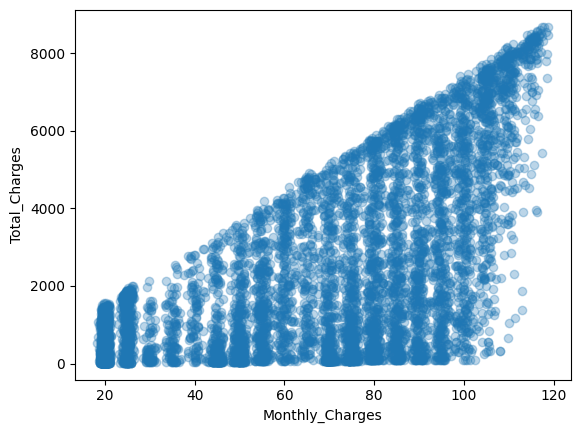

In [30]:
plt.scatter(df['MonthlyCharges'],df['TotalCharges'],alpha=0.3)
plt.xlabel('Monthly_Charges')
plt.ylabel('Total_Charges')
plt.show()

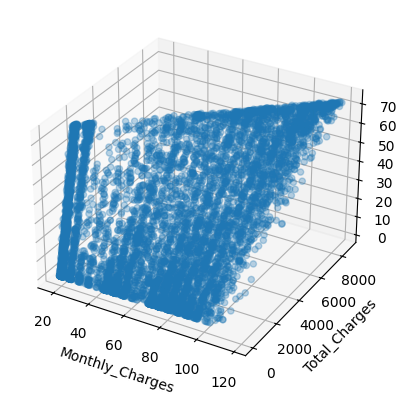

In [32]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['MonthlyCharges'],
    df['TotalCharges'],
    df['tenure'],
    alpha=0.3
)

ax.set_xlabel('Monthly_Charges')
ax.set_ylabel('Total_Charges')
ax.set_zlabel('tenure')

plt.show()

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [36]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.83      0.90      0.87      1033
        True       0.65      0.51      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.79      0.80      0.79      1407



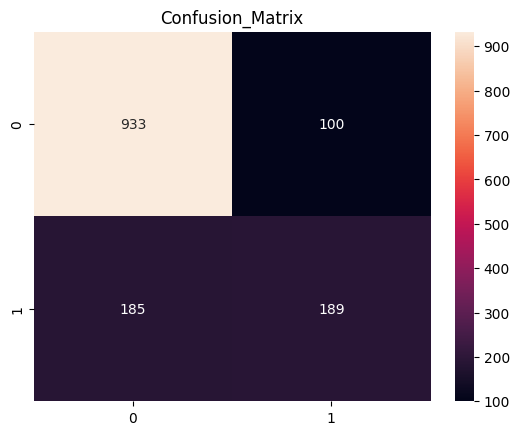

In [37]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title('Confusion_Matrix')
plt.show()

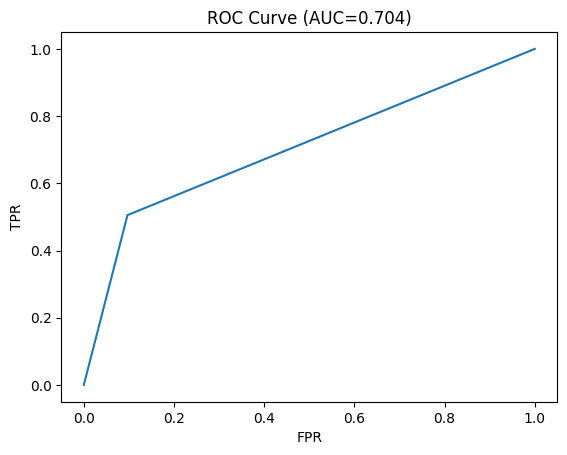

In [38]:
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test,y_pred)

plt.plot(fpr,tpr)
plt.title("ROC Curve (AUC="+str(np.round(auc,3))+")")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [41]:
X.dtypes

,0
SeniorCitizen,int64
tenure,int64
MonthlyCharges,float64
TotalCharges,float64
charges_per_month,float64
...,...
PaymentMethod_Mailed check,bool
tenure_group_12-24,bool
tenure_group_24-48,bool
tenure_group_48-60,bool


In [42]:
X_numeric = X.select_dtypes(include=['number'])

In [43]:
X = pd.get_dummies(X, drop_first=True)

In [44]:
X = X.apply(pd.to_numeric)

In [45]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Keep only numeric columns
X_numeric = X.select_dtypes(include=[np.number])

# Remove inf and NaN
X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan)
X_numeric = X_numeric.dropna()

# Add constant
X_vif = sm.add_constant(X_numeric)

# Convert to numpy explicitly (IMPORTANT)
X_values = X_vif.values

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_values, i)
    for i in range(X_values.shape[1])
]

vif

,Feature,VIF
0,const,15.298816
1,SeniorCitizen,1.054459
2,tenure,5.963403
3,MonthlyCharges,17.863104
4,TotalCharges,10.070693
5,charges_per_month,20.851008


In [50]:
model_l2 = LogisticRegression(penalty='l2', solver='liblinear')
model_l2.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [51]:
model_l1 = LogisticRegression(penalty='l1', solver='liblinear')
model_l1.fit(X_train, y_train)

LogisticRegression(penalty='l1', solver='liblinear')

In [52]:
import numpy as np

probs = model.predict_proba(X_test)[:,1]
threshold = 0.4

y_pred_new = (probs >= threshold).astype(int)
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

       False       0.86      0.83      0.84      1033
        True       0.57      0.64      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.72      1407
weighted avg       0.79      0.78      0.78      1407

